# トレーニング効果の検証に向けた統計検定

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel(r"F:\Je respire\トレーニング後\トレーニング前後比較.xlsx")

In [8]:
df.head()

,subject,question,q_category,score,left_pupil_std,right_pupil_std,CH1_std,CH2_std,CH3_std,CH4_std,...,CD_RISC_total,CD_RISC_reading,CD_RISC_memory,CD_RISC_recognition,CD_RISC_attention,SRS_18,ERQ_reevaluation_total,ERQ_reevaluation_ave,ERQ_suppression_total,ERQ_suppression_ave
0,3,1,1,2,0.380827,0.271983,1.182634,0.973981,0.840443,1.517479,...,74,14,16,15,15,4,36,6.0,22,5.5
1,3,8,2,2,-0.462448,-0.538958,0.595958,1.009921,0.026125,0.973451,...,74,14,16,15,15,4,36,6.0,22,5.5
2,3,5,1,2,-0.140344,-0.147450,1.080476,1.173780,0.203121,0.862638,...,74,14,16,15,15,4,36,6.0,22,5.5
3,3,21,4,2,1.092684,1.000796,1.524975,1.466847,0.091430,0.200126,...,74,14,16,15,15,4,36,6.0,22,5.5
4,3,18,3,0,0.271099,0.159905,1.500132,1.677728,0.280140,0.307397,...,74,14,16,15,15,4,36,6.0,22,5.5


3(nagashio) before 0-23, after 72-95  
4(yanaze) before 24-47, after 48-71

In [4]:
df_before = df.iloc[0:48]
df_after = df.iloc[48:96]

In [9]:
# データ型を確認
print("データ型:")
print(df.dtypes)
print("\nデータの形状:", df.shape)
print("\n列名:")
print(df.columns.tolist())

データ型:
subject                    object
question                    int64
q_category                  int64
score                       int64
left_pupil_std            float64
                           ...   
SRS_18                      int64
ERQ_reevaluation_total      int64
ERQ_reevaluation_ave      float64
ERQ_suppression_total       int64
ERQ_suppression_ave       float64
Length: 95, dtype: object

データの形状: (96, 95)

列名:
['subject', 'question', 'q_category', 'score', 'left_pupil_std', 'right_pupil_std', 'CH1_std', 'CH2_std', 'CH3_std', 'CH4_std', 'CH5_std', 'CH6_std', 'CH7_std', 'CH8_std', 'CH9_std', 'right_haigai', 'CH10_std', 'CH11_std', 'CH12_std', 'CH13_std', 'hainai', 'CH14_std', 'CH15_std', 'CH16_std', 'CH17_std', 'CH18_std', 'left_haigai', 'CH19_std', 'CH20_std', 'CH21_std', 'CH22_std', 'CH1.1_std', 'CH2.1_std', 'CH3.1_std', 'CH4.1_std', 'CH5.1_std', 'CH6.1_std', 'CH7.1_std', 'CH8.1_std', 'CH9.1_std', 'CH10.1_std', 'CH11.1_std', 'CH12.1_std', 'CH13.1_std', 'CH14.1_std', 'CH1

In [10]:
from scipy import stats
import numpy as np

# 統計検定の結果を格納するリスト
results = []

# 数値型の列のみを対象とする
numeric_columns = df_before.select_dtypes(include=[np.number]).columns

# 各列について検定を実施
for col in numeric_columns:
    before_data = df_before[col].dropna()
    after_data = df_after[col].dropna()
    
    # サンプルサイズが異なる場合やサンプル数が少ない場合はスキップ
    if len(before_data) != len(after_data) or len(before_data) < 3:
        continue
    
    try:
        # 基本統計量
        before_mean = before_data.mean()
        after_mean = after_data.mean()
        before_median = before_data.median()
        after_median = after_data.median()
        
        # 正規性検定（Shapiro-Wilk検定）
        _, p_shapiro_before = stats.shapiro(before_data)
        _, p_shapiro_after = stats.shapiro(after_data)
        is_normal = p_shapiro_before > 0.05 and p_shapiro_after > 0.05
        
        # 対応のあるt検定 vs Wilcoxon符号順位検定
        if is_normal:
            t_stat, p_value = stats.ttest_rel(before_data, after_data)
            test_name = "対応のあるt検定"
        else:
            w_stat, p_value = stats.wilcoxon(before_data, after_data)
            test_name = "Wilcoxon符号順位検定"
        
        results.append({
            '列名': col,
            '検定手法': test_name,
            'Before 平均': f"{before_mean:.4f}",
            'After 平均': f"{after_mean:.4f}",
            '平均値差': f"{after_mean - before_mean:.4f}",
            'Before 中央値': f"{before_median:.4f}",
            'After 中央値': f"{after_median:.4f}",
            '中央値差': f"{after_median - before_median:.4f}",
            'p値': f"{p_value:.6f}",
            '有意差': 'あり' if p_value < 0.05 else 'なし'
        })
    except Exception as e:
        continue

# 結果をDataFrameに変換して表示
results_df = pd.DataFrame(results)
print(f"検定実施列数: {len(results_df)}\n")
print(results_df.to_string(index=False))

検定実施列数: 46

                                 列名           検定手法 Before 平均 After 平均    平均値差 Before 中央値 After 中央値    中央値差       p値 有意差
                           question       対応のあるt検定   12.5000  12.5000  0.0000    12.5000   12.5000  0.0000 1.000000  なし
                         q_category Wilcoxon符号順位検定    2.5000   2.5000  0.0000     2.5000    2.5000  0.0000 0.976857  なし
                              score Wilcoxon符号順位検定    1.1042   1.4375  0.3333     1.0000    2.0000  1.0000 0.072738  なし
                            CH1_std Wilcoxon符号順位検定    0.3275  -0.2361 -0.5636     0.1288    0.0000 -0.1288 0.000000  あり
                            CH2_std Wilcoxon符号順位検定    0.3193  -0.3074 -0.6267     0.1835   -0.1517 -0.3352 0.000002  あり
                            CH3_std Wilcoxon符号順位検定   -0.2193  -0.3067 -0.0875    -0.1067    0.0000  0.1067 0.479393  なし
                            CH4_std Wilcoxon符号順位検定    0.0793   0.2478  0.1685     0.0943    0.1002  0.0059 0.551799  なし
                            

c:\WorkSpace\GitHub\je\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\WorkSpace\GitHub\je\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


有意差のある列: 19 個
['CH1_std', 'CH2_std', 'CH8_std', 'CH13_std', 'hainai', 'CH18_std', 'CH21_std', 'CH22_std', '[G] Heart Rate_std', 'CD_RISC_total']


C:\Users\human1\AppData\Local\Temp\ipykernel_6176\2826846760.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True)
C:\Users\human1\AppData\Local\Temp\ipykernel_6176\2826846760.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True)
C:\Users\human1\AppData\Local\Temp\ipykernel_6176\2826846760.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True)
C:\Users\human1\AppData\Local\Temp\ipykernel_6176\28

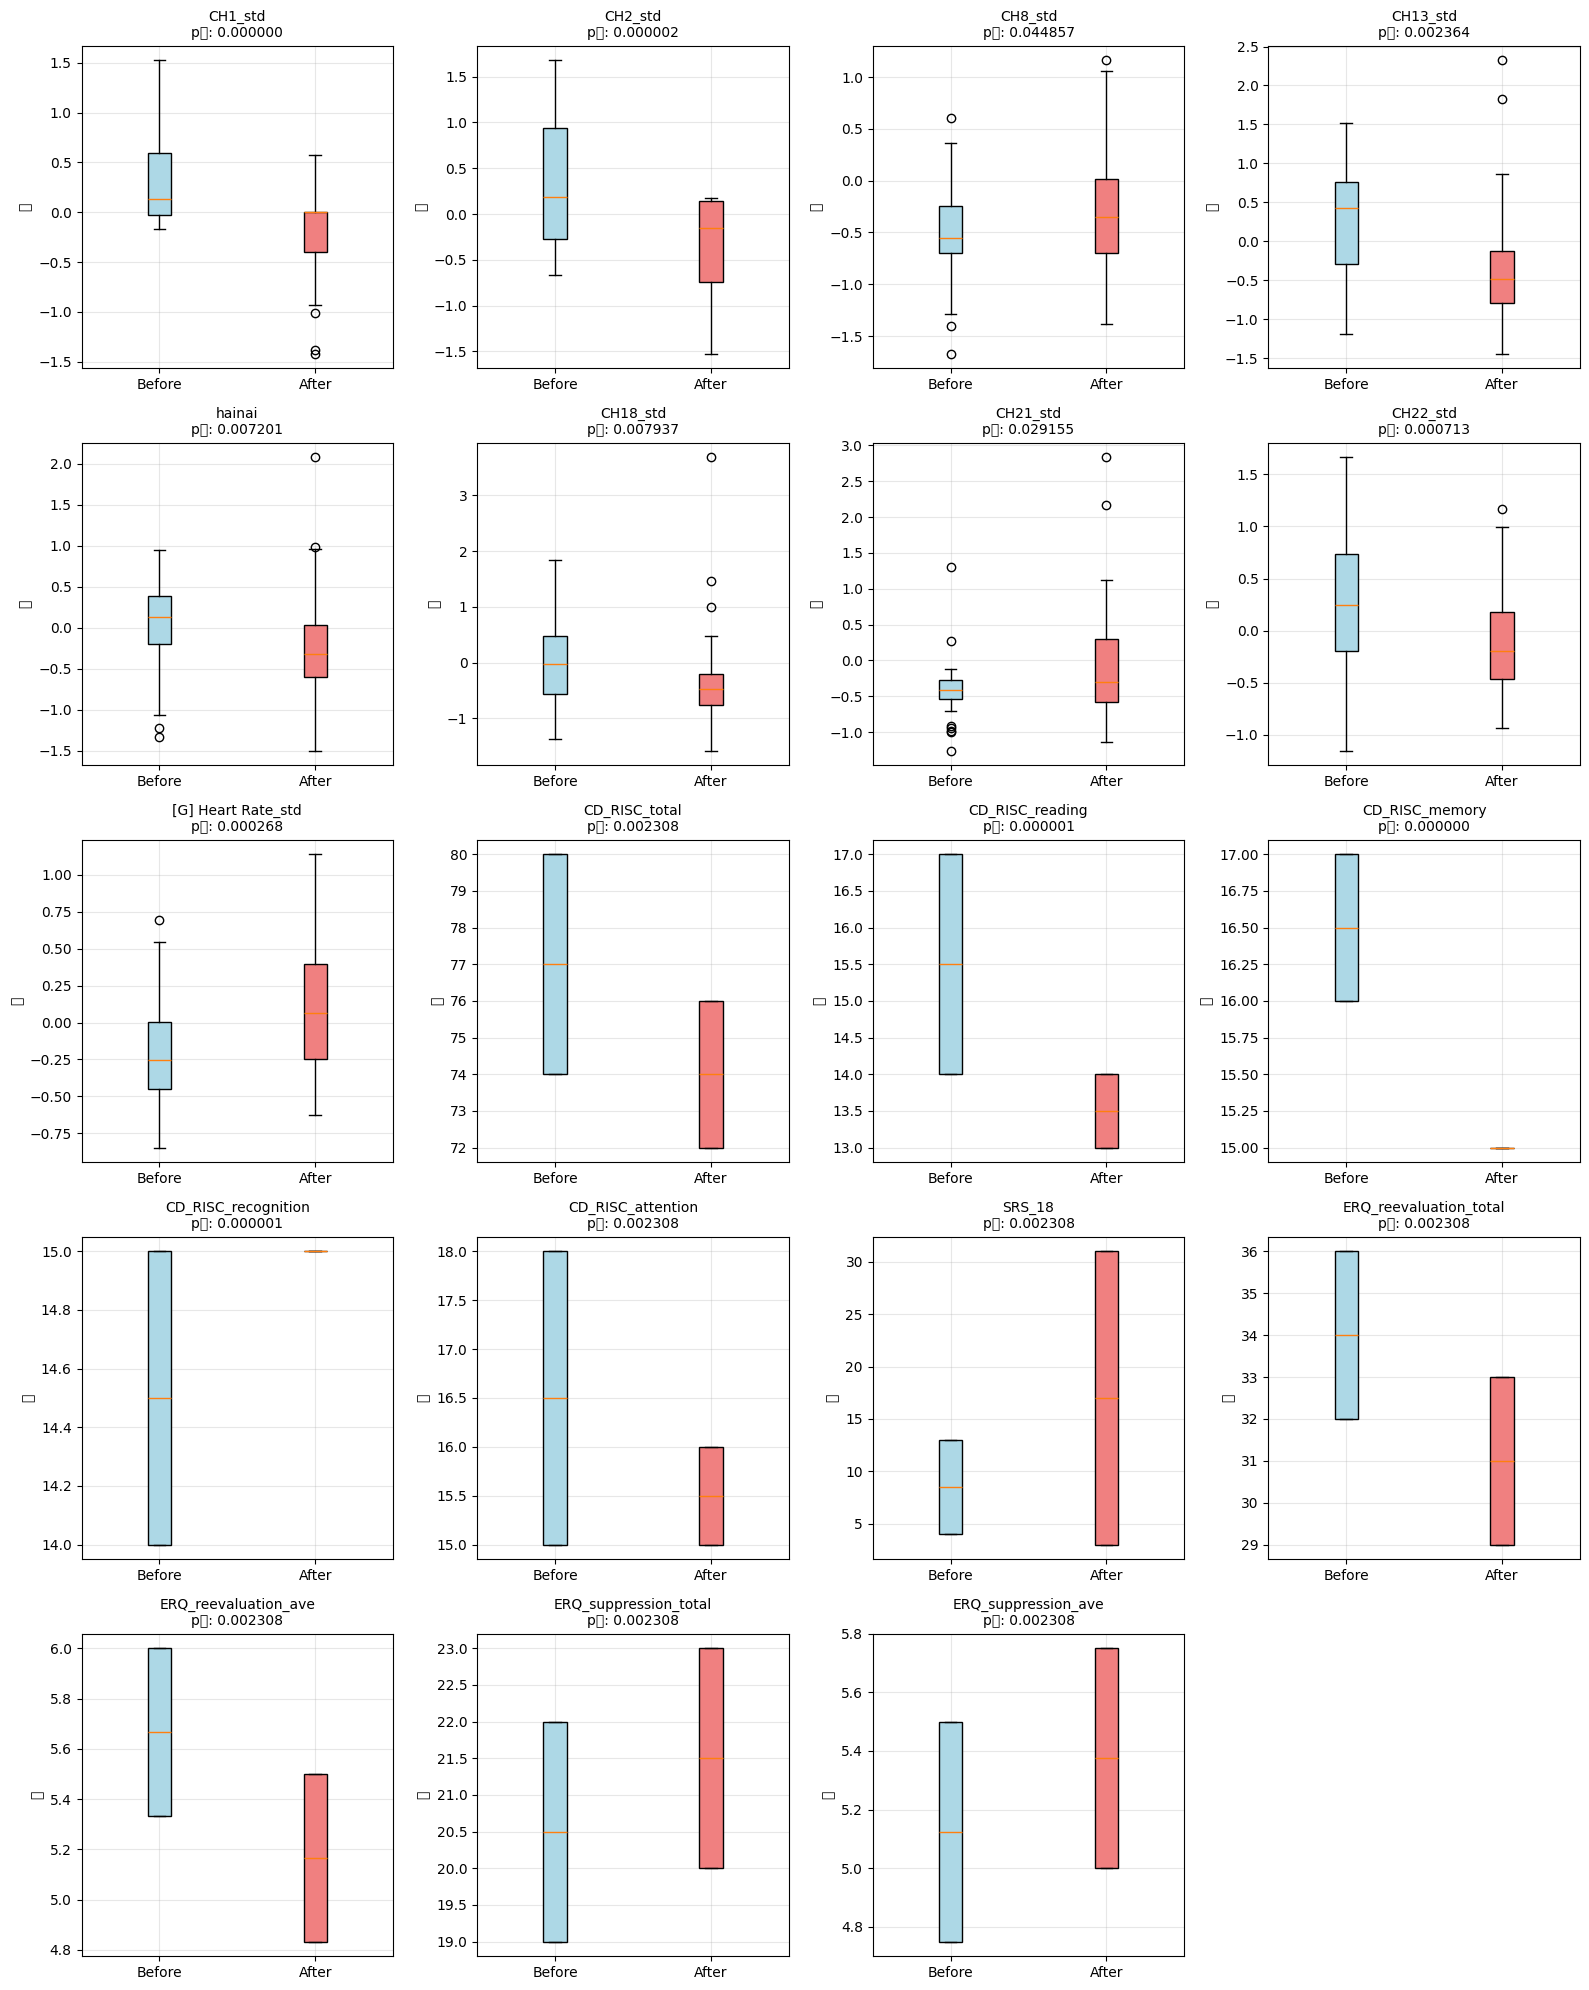

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 有意差のある列を抽出
significant_cols = results_df[results_df['有意差'] == 'あり']['列名'].tolist()

print(f"有意差のある列: {len(significant_cols)} 個")
print(significant_cols[:10])  # 最初の10個を表示

# 有意差がある列について箱ひげ図を描画
if len(significant_cols) > 0:
    # 列数に応じて行数と列数を決定
    n_cols = min(4, len(significant_cols))  # 最大4列
    n_rows = (len(significant_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes = axes.flatten() if len(significant_cols) > 1 else [axes]
    
    for idx, col in enumerate(significant_cols):
        ax = axes[idx]
        
        # Box plotを描画
        data_to_plot = [df_before[col].dropna(), df_after[col].dropna()]
        bp = ax.boxplot(data_to_plot, labels=['Before', 'After'], patch_artist=True)
        
        # 色を設定
        colors = ['lightblue', 'lightcoral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        # タイトルとラベル
        p_val = float(results_df[results_df['列名'] == col]['p値'].values[0])
        ax.set_title(f'{col}\np値: {p_val:.6f}', fontsize=10)
        ax.set_ylabel('値')
        ax.grid(True, alpha=0.3)
    
    # 不要なサブプロットを削除
    for idx in range(len(significant_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
else:
    print("有意差のある列がありません")

In [6]:
df_after.tail()


,subject,question,q_category,score,left_pupil_std,right_pupil_std,CH1_std,CH2_std,CH3_std,CH4_std,...,CD_RISC_total,CD_RISC_reading,CD_RISC_memory,CD_RISC_recognition,CD_RISC_attention,SRS_18,ERQ_reevaluation_total,ERQ_reevaluation_ave,ERQ_suppression_total,ERQ_suppression_ave
91,3_2,1,1,2,0.360090,0.292606,-1.382977,-0.368862,-0.815615,-0.393965,...,72,13,15,15,15,3,33,5.5,23,5.75
92,3_2,9,2,2,-0.258818,-0.328705,-1.418517,-0.784160,-1.095582,-0.709014,...,72,13,15,15,15,3,33,5.5,23,5.75
93,3_2,18,3,2,-0.252674,-0.363038,-1.010152,-0.391844,-1.179098,-0.875616,...,72,13,15,15,15,3,33,5.5,23,5.75
94,3_2,13,3,0,0.467650,0.390016,-0.932460,-0.149038,-0.961132,-1.017652,...,72,13,15,15,15,3,33,5.5,23,5.75
95,3_2,20,4,1,0.452234,0.462808,-0.121156,-0.030608,-0.267256,-0.180819,...,72,13,15,15,15,3,33,5.5,23,5.75


In [ ]:
from scipy import stats
import numpy as np

# 統計検定の結果を格納するリスト
results = []

# 数値型の列のみを対象とする
numeric_columns = df_before.select_dtypes(include=[np.number]).columns

# 各列について検定を実施
for col in numeric_columns:
    before_data = df_before[col].dropna()
    after_data = df_after[col].dropna()
    
    # サンプルサイズが異なる場合はスキップ
    if len(before_data) != len(after_data) or len(before_data) < 3:
        continue
    
    try:
        # 基本統計量
        before_mean = before_data.mean()
        after_mean = after_data.mean()
        before_median = before_data.median()
        after_median = after_data.median()
        
        # 正規性検定（Shapiro-Wilk検定）
        _, p_shapiro_before = stats.shapiro(before_data)
        _, p_shapiro_after = stats.shapiro(after_data)
        is_normal = p_shapiro_before > 0.05 and p_shapiro_after > 0.05
        
        # 対応のあるt検定 vs Wilcoxon符号順位検定
        if is_normal:
            t_stat, p_value = stats.ttest_rel(before_data, after_data)
            test_name = "対応のあるt検定"
        else:
            w_stat, p_value = stats.wilcoxon(before_data, after_data)
            test_name = "Wilcoxon符号順位検定"
        
        results.append({
            '列名': col,
            '検定手法': test_name,
            'Before 平均': f"{before_mean:.4f}",
            'After 平均': f"{after_mean:.4f}",
            '平均値差': f"{after_mean - before_mean:.4f}",
            'Before 中央値': f"{before_median:.4f}",
            'After 中央値': f"{after_median:.4f}",
            '中央値差': f"{after_median - before_median:.4f}",
            'p値': f"{p_value:.6f}",
            '有意差': 'あり' if p_value < 0.05 else 'なし'
        })
    except Exception as e:
        continue

# 結果をDataFrameに変換して表示
results_df = pd.DataFrame(results)
print(f"検定実施列数: {len(results_df)}")
print("\n", results_df.to_string(index=False))

TypeError: Could not convert string '4_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_24_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_23_2' to numeric